In [1]:
import pandas as pd
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats import multitest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import compress

In [2]:
def itertool_stats(dict, method, key = None, ns = None):
    for subset in itertools.combinations(dict.keys(), 2):
        if method == 'chi2_contingency':
            stat, p, dof, expected  = stats.chi2_contingency([[dict[subset[0]], ns[subset[0]] - dict[subset[0]]],
                                                [dict[subset[1]], ns[subset[1]] - dict[subset[1]]]])
            print(subset, p)
        elif method == 'fisher':
            oddsratio, p  = stats.fisher_exact([dict[subset[0]],
                                        dict[subset[1]]])
            print(subset, p)
        elif method == 'ttest':
            stat, p = stats.ttest_ind(dict[subset[0]],
                                       dict[subset[1]],
                                       equal_var = False)
            print(subset, p)

In [3]:
def cell_group_import(channel):
    dfs = []
    all_files = glob.glob(os.path.join('data/' + '*' + channel + '.feather'))

    for file in all_files:
        df = pd.read_feather(file)
        id = df['Image'][0][:11]
        if id == '2021_04_10_':
            id = 'BRAC5112.5g'
        df = df.groupby(['BrainRegion', 'Class']).size().reset_index(name='Num_cells')
        #df = df.groupby(['BrainRegion']).size().reset_index(name='Num_cells')
        df['id'] = id
        df['channel'] = channel
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index = True)
    
    return data

def area_import():
    dfs = []
    all_files = glob.glob(os.path.join('Allen_area',  '*.csv'))
    for file in all_files:
        df = pd.read_csv(file)
        df['id'] = file[11:22]
        dfs.append(df)
    data = pd.concat(dfs, ignore_index = True)
    data.rename(columns={'Name': 'BrainRegion'}, inplace=True)
    return data

In [4]:
sns.set_context("notebook", rc={"font.family": 'sans-serif',
                                'font.sans-serif': 'DejaVu Sans'})

import cfos, DAPI and state data

In [5]:
areas = pd.read_csv('selected_area.csv', encoding='cp1252')['area'].tolist()
area_abbr_mapping = pd.read_csv('selected_area.csv', encoding='cp1252').set_index('area')['abbr'].to_dict()
# abbr = pd.read_csv('selected_area.csv', encoding='cp1252')['abbr'].tolist()

In [6]:
state = pd.read_csv('state.csv', encoding='cp1252')
dfs = []
merged_df = cell_group_import('cfos')
area = area_import()

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_64467/845270567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(['BrainRegion', 'Class']).size().reset_index(name='Num_cells')
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_64467/845270567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(['BrainRegion', 'Class']).size().reset_index(name='Num_cells')
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_64467/845270567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pa

In [7]:
merged_df.to_csv('cfos.csv')

In [8]:
merged_df = merged_df.merge(area, how = 'left', on=['id', 'BrainRegion'])
merged_df['cfos/area'] = merged_df[merged_df['Class'] == 'positive']['Num_cells'] / merged_df['total_area'] *1000000
#merged_df['cfos/area'] = merged_df['Num_cells'] / merged_df['total_area'] *1000000
merged_df = merged_df.merge(state, how = 'left', on = 'id')

In [9]:
print(merged_df[merged_df['state_after'] == 'Agg+']['id'].unique())
print(merged_df[merged_df['state_after'] == 'Agg-']['id'].unique())

['BRAC5872.1f' 'BRAC5872.1g' 'BRAC5603.3e' 'BRAC5487.3j' 'BRAC5872.1d'
 'BRAC5872.1c']
['BRAC5487.3i' 'BRAC5112.5g' 'BRAC5487.3k' 'BRAC5481.2e' 'BRAC5603.3f']


In [10]:
p = []
reg = []
for region in areas:
    agg_plus = merged_df[(merged_df['BrainRegion'] == region) & 
                         (merged_df['Class'] == 'positive') & 
                         (merged_df['state_after'] == 'Agg+')]['cfos/area'].fillna(0).tolist()
    agg_minus = merged_df[(merged_df['BrainRegion'] == region) &  
                          (merged_df['Class'] == 'positive') & 
                          (merged_df['state_after'] == 'Agg-')]['cfos/area'].fillna(0).tolist()
    
    stats1, p1 = stats.mannwhitneyu(agg_plus,
                                   agg_minus)
    p.append(p1)
    reg.append(region)
    #print(p1, agg_plus, agg_minus, region)

        
p_corrected = multitest.multipletests(p, method = 'fdr_bh')
positive_ls = list(compress(reg, p_corrected[0]))

positive_p = list(compress(p, p_corrected[0]))

print([ (l, p) for l,p in zip(positive_ls, positive_p)])
positive_ls.extend(['Paraventricular nucleus of the thalamus',
                   'Cortical amygdalar area, posterior part, lateral zone',
                   'Cortical amygdalar area, posterior part, medial zone',
                  'Medial amygdalar nucleus', 'Ventromedial hypothalamic nucleus'])

[('Anteroventral preoptic nucleus', 0.004329004329004329), ('Lateral preoptic area', 0.004329004329004329), ('Medial preoptic area', 0.004329004329004329), ('Parastrial nucleus', 0.004329004329004329), ('Tuberal nucleus', 0.004329004329004329)]


In [11]:
p_corrected[1]

array([0.24218374, 0.24218374, 0.24218374, 0.51285969, 0.07647908,
       0.04588745, 0.51285969, 0.79781582, 0.56785714, 1.        ,
       0.45096283, 1.        , 1.        , 0.45096283, 0.51285969,
       1.        , 0.91276115, 0.24218374, 0.21178821, 0.56785714,
       0.17845118, 0.79781582, 0.79781582, 0.51285969, 0.37627706,
       0.04588745, 0.56785714, 0.04588745, 0.21178821, 0.11471861,
       0.24218374, 0.37627706, 0.51285969, 0.21178821, 1.        ,
       0.37627706, 0.56785714, 0.37627706, 0.21178821, 0.56785714,
       1.        , 0.79781582, 0.04588745, 0.37627706, 0.33268398,
       0.04588745, 0.56785714, 0.91276115, 0.45096283, 0.94866599,
       0.45096283, 0.11471861, 0.33268398])

In [12]:
print(merged_df[ (merged_df['Class'] == 'positive') &
                (merged_df['BrainRegion'].isin(positive_ls))]['BrainRegion'].unique())
#abbr = ['AVPV','COApl', 'COApm', 'LPOA', 'MEA', 
#        'MPOA', 'PS', 'PVT','TU', 'VMH']

['Anteroventral preoptic nucleus'
 'Cortical amygdalar area, posterior part, lateral zone'
 'Cortical amygdalar area, posterior part, medial zone'
 'Lateral preoptic area' 'Medial amygdalar nucleus' 'Medial preoptic area'
 'Parastrial nucleus' 'Paraventricular nucleus of the thalamus'
 'Tuberal nucleus' 'Ventromedial hypothalamic nucleus']


In [13]:
# reorder BrainRegion column based on list area
categ = merged_df[(merged_df['BrainRegion'].isin(areas)) & 
                         (merged_df['Class'] == 'positive')]
categ.BrainRegion = categ.BrainRegion.astype("category")
categ.BrainRegion.cat.set_categories(areas)
categ = categ.sort_values(['BrainRegion'])
# categ['BrainRegion'] = categ['BrainRegion'].cat.codes
categ['brain_abbr' ] = categ['BrainRegion'].map(area_abbr_mapping)

categ['brain_abbr' ] = categ['brain_abbr'].astype('str')


/Users/kohlj/opt/anaconda3/lib/python3.7/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


/Users/kohlj/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


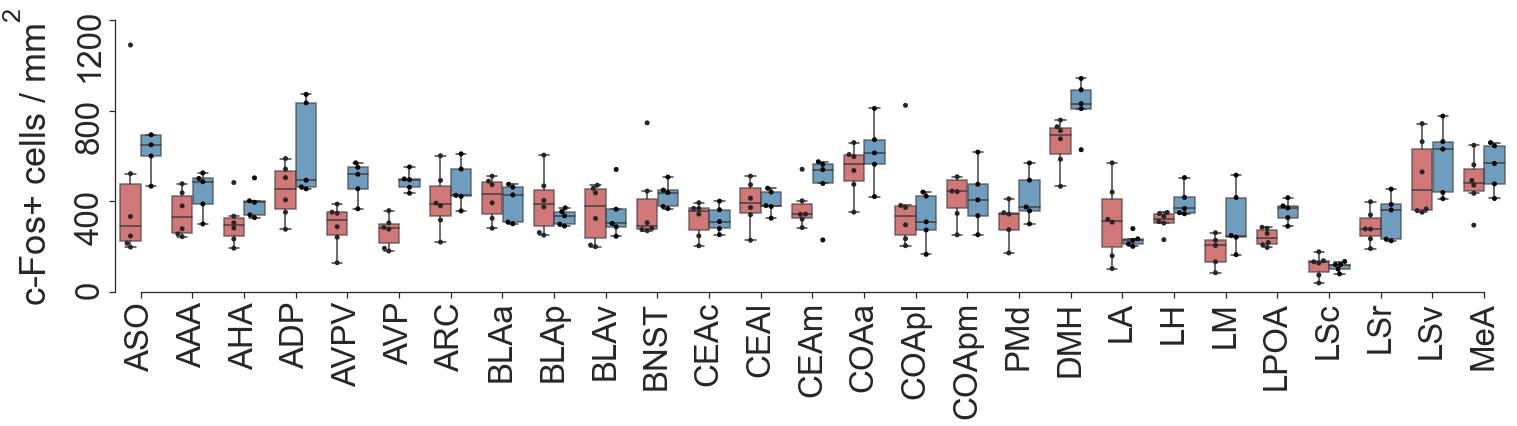

In [14]:
sns.set(rc={'figure.figsize':(25,5)})
sns.set(font_scale=3)
sns.set_style("ticks")
fig,ax = plt.subplots()
sns.swarmplot(x = 'brain_abbr', 
              y = 'cfos/area', 
              hue = 'state_after', 
              data = categ[:27*11-1] ,
              dodge = True,
              color = 'black')

g = sns.boxplot(x = 'brain_abbr', 
            y = 'cfos/area', 
            hue = 'state_after', 
            data = categ[:27*11-1], 
            dodge = True, 
            palette = ['Tab:red', 'Tab:blue'],
            boxprops=dict(alpha=.7), showfliers=False)

handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles[2:4], labels[2:4],
                bbox_to_anchor=(1, 1), 
                loc=2, borderaxespad=0,
                fontsize='large',
                handletextpad = 0.5)
plt.xlabel(None)
plt.ylabel('c-Fos+ cells / $\mathregular{mm^{2}}$', labelpad=20)
plt.yticks(rotation = 90)
plt.xticks(rotation=90)
ax.legend_.remove()
plt.ylim(0,1200)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/cfos_1.pdf',
dpi=600,bbox_inches='tight', transparent=True)

In [17]:
# change PVH -> PVH
categ['brain_abbr'] = categ['brain_abbr'].replace('PVN', 'PVH')

/Users/kohlj/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


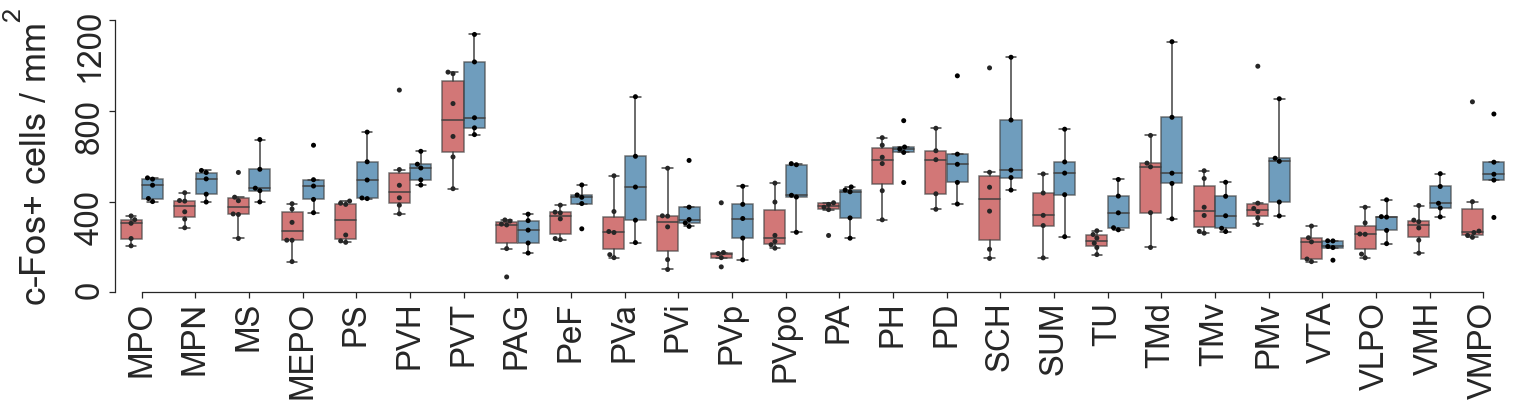

In [18]:
sns.set(rc={'figure.figsize':(25,5)})
sns.set(font_scale=3)
sns.set_style("ticks")
fig,ax = plt.subplots()
sns.swarmplot(x = 'brain_abbr', 
              y = 'cfos/area', 
              hue = 'state_after', 
              data = categ[27*11:] ,
              dodge = True,
              color = 'black')

g = sns.boxplot(x = 'brain_abbr', 
            y = 'cfos/area', 
            hue = 'state_after', 
            data = categ[27*11:], 
            dodge = True, 
            palette = ['Tab:red', 'Tab:blue'],
            boxprops=dict(alpha=.7), showfliers=False)

handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles[2:4], labels[2:4],
                bbox_to_anchor=(1, 1), 
                loc=2, borderaxespad=0,
                fontsize='large',
                handletextpad = 0.5)
plt.xlabel(None)
plt.ylabel('c-Fos+ cells / $\mathregular{mm^{2}}$', labelpad=20)
plt.yticks(rotation = 90)
plt.xticks(rotation=90)
ax.legend_.remove()
plt.ylim(0,1200)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(trim=True)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/cfos_2.pdf',
dpi=600,bbox_inches='tight', transparent=True)